In [1]:
!pip install trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 704.4/704.4 kB 41.7 MB/s eta 0:00:00


In [2]:
import trimesh
import numpy as np
import plotly.graph_objs as go
from tqdm import tqdm

# Indices des points de départ (les points de référence pour les distances géodésiques)
seed_index1 = 13714
seed_index2 = 22947
seed_index3 = 22340

def load_obj_mesh(filepath):
    """
    Charge un fichier .obj et extrait les sommets et les faces.

    Paramètres :
        filepath (str) : Chemin vers le fichier .obj.

    Retourne :
        vertices (ndarray) : Tableau Nx3 des sommets.
        faces (ndarray) : Tableau Mx3 des indices des faces.
    """
    mesh = trimesh.load(filepath)
    vertices = np.array(mesh.vertices)
    faces = np.array(mesh.faces)
    return vertices, faces

def custom_dijkstra(graph, start_vertex):
    """
    Implémente l'algorithme de Dijkstra pour calculer les distances les plus courtes depuis un sommet de départ.

    Paramètres :
        graph (ndarray) : Matrice d'adjacence pondérée représentant le graphe.
        start_vertex (int) : Index du sommet de départ.

    Retourne :
        distances (ndarray) : Tableau des distances depuis le sommet de départ vers chaque autre sommet.
    """
    num_vertices = graph.shape[0]
    distances = np.full(num_vertices, np.inf)  # Initialiser les distances à l'infini
    distances[start_vertex] = 0  # La distance au sommet de départ est zéro
    visited = np.zeros(num_vertices, dtype=bool)  # Tableau pour suivre les sommets visités

    for _ in range(num_vertices):
        # Trouver le sommet non visité avec la plus petite distance
        min_dist = np.inf
        min_index = -1
        for i in range(num_vertices):
            if not visited[i] and distances[i] < min_dist:
                min_dist = distances[i]
                min_index = i

        # Si aucune mise à jour n'est possible, arrêter
        if min_index == -1:
            break

        # Marquer le sommet comme visité
        visited[min_index] = True

        # Mettre à jour les distances pour les voisins non visités
        for neighbor in range(num_vertices):
            if graph[min_index, neighbor] > 0 and not visited[neighbor]:
                new_distance = distances[min_index] + graph[min_index, neighbor]
                if new_distance < distances[neighbor]:
                    distances[neighbor] = new_distance

    return distances

def compute_geodesic_distances(vertices, faces, seed_index, margin):
    """
    Calcule les distances géodésiques à partir d'un sommet de départ pour tous les autres sommets du maillage.

    Paramètres :
        vertices (ndarray) : Tableau Nx3 des sommets.
        faces (ndarray) : Tableau Mx3 des indices des faces.
        seed_index (int) : Index du sommet de départ pour les calculs de distance.

    Retourne :
        distances (ndarray) : Tableau des distances à partir du sommet de départ.
    """
    # Accumuler les arêtes et leurs distances
    num_vertices = len(vertices)
    graph = np.zeros((num_vertices, num_vertices))

    for face in tqdm(faces, desc="Construction du graphe"):
        for i in range(3):
            for j in range(i + 1, 3):
                vi, vj = face[i], face[j]
                dist = np.linalg.norm(vertices[vi] - vertices[vj])

                # Ajouter la distance dans la matrice du graphe
                graph[vi, vj] = dist
                graph[vj, vi] = dist

    # Utiliser l'algorithme personnalisé de Dijkstra
    distances = custom_dijkstra(graph, seed_index)

    return distances

def compute_sum_of_distances(vertices, faces, reference_point1, reference_point2, reference_point3):
    """
    Calcule la somme des distances géodésiques depuis trois points de référence.

    Paramètres :
        vertices (ndarray) : Tableau Nx3 des sommets.
        faces (ndarray) : Tableau Mx3 des indices des faces.
        reference_point1 (int) : Index du premier point de référence.
        reference_point2 (int) : Index du deuxième point de référence.
        reference_point3 (int) : Index du troisième point de référence.

    Retourne :
        sum_distances (ndarray) : Tableau des sommes des distances géodésiques.
    """
    d1 = compute_geodesic_distances(vertices, faces, reference_point1, margin=0)
    d2 = compute_geodesic_distances(vertices, faces, reference_point2, margin=0)
    d3 = compute_geodesic_distances(vertices, faces, reference_point3, margin=0)

    sum_distances = np.abs(d1 + (d2 + d3))
    return sum_distances

def plot_bipolar_contours(vertices, faces, sum_distances, target_distances, tolerance):
    """
    Trace des contours 3D basés sur la somme des distances géodésiques.

    Paramètres :
        vertices (ndarray) : Tableau Nx3 des sommets.
        faces (ndarray) : Tableau Mx3 des indices des faces.
        sum_distances (ndarray) : Tableau des sommes des distances géodésiques.
        target_distances (list) : Liste des distances cibles pour les contours.
        tolerance (float) : Tolérance pour la sélection des sommets dans le contour.
    """
    x, y, z = vertices[:, 0], vertices[:, 1], vertices[:, 2]
    mesh3d = go.Mesh3d(
        x=x, y=y, z=z,
        i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
        intensity=sum_distances,
        colorscale='Viridis',
        colorbar_title='Somme des distances géodésiques',
        showscale=True,
        opacity=0.8
    )

    # Tracer les points de référence
    seed_markers = []
    for seed_index, color in zip([seed_index1, seed_index2, seed_index3], ['orange', 'red', 'green']):
        seed_vertex = vertices[seed_index]
        seed_marker = go.Scatter3d(
            x=[seed_vertex[0]], y=[seed_vertex[1]], z=[seed_vertex[2]],
            mode='markers',
            marker=dict(size=10, color=color, symbol='circle'),
            name=f"Point de départ {seed_index}"
        )
        seed_markers.append(seed_marker)

    # Tracer les contours pour chaque distance cible
    contours = []
    for target_distance in target_distances:
        selected_indices = np.where(np.isclose(sum_distances, target_distance, atol=tolerance))[0]
        selected_vertices = vertices[selected_indices]

        contour = go.Scatter3d(
            x=selected_vertices[:, 0], y=selected_vertices[:, 1], z=selected_vertices[:, 2],
            mode='markers',
            marker=dict(size=2, color='blue', symbol='circle'),
            name=f"Contour à {target_distance}"
        )
        contours.append(contour)

    # Mise en page
    layout = go.Layout(
        scene=dict(
            xaxis=dict(title='X'),
            yaxis=dict(title='Y'),
            zaxis=dict(title='Z')
        ),
        title="Contours bipolaires basés sur les distances géodésiques",
        width=800,
        height=600
    )

    # Créer et afficher la figure
    fig = go.Figure(data=[mesh3d] + seed_markers + contours, layout=layout)
    fig.show()

# Charger le maillage depuis un fichier .obj
filepath = '/content/F0001_AN01WH_F3Dsur.obj'  # Remplacez par le chemin de votre fichier
vertices, faces = load_obj_mesh(filepath)

# Calculer la somme des distances géodésiques
sum_distances = compute_sum_of_distances(vertices, faces, seed_index1, seed_index2, seed_index3)

# Spécifier les distances cibles pour les contours
target_distances = [104, 119, 129, 139, 149, 159, 174]  # Modifiez selon vos besoins

# Tracer les contours bipolaires
plot_bipolar_contours(vertices, faces, sum_distances, target_distances, tolerance=0.26)


Construction du graphe: 100%|██████████| 61224/61224 [00:01<00:00, 54026.27it/s]




---

# Essais de récalage avec ICP (estimation de rotation + translation itérative)

---



In [40]:
import trimesh
import numpy as np
import plotly.graph_objs as go
from sklearn.neighbors import KDTree
from tqdm import tqdm

# ICP functions (reused from your code)
def FindNeighborPoints(source_pts, target_pts):
    """
    Find the closest points in target_pts for each point in source_pts.
    """
    tree = KDTree(target_pts)
    dist, indices = tree.query(source_pts, k=1)
    return target_pts[indices[:, 0]]

def RegisterPoints(source_pts, target_pts):
    """
    Compute the optimal rigid transformation (rotation and translation) to align source_pts to target_pts.
    """
    source_mean = np.mean(source_pts, axis=0)
    target_mean = np.mean(target_pts, axis=0)

    source_centered = source_pts - source_mean
    target_centered = target_pts - target_mean

    H = source_centered.T @ target_centered
    U, _, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T

    # Handle reflection case
    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T

    t = target_mean.T - R @ source_mean.T
    return R, t

def ApplyTransformation(pts, R, t):
    """
    Apply rotation R and translation t to a set of points.
    """
    return (R @ pts.T).T + t.T

def ComputeRMSE(source_pts, target_pts):
    """
    Compute RMSE between two sets of points.
    """
    return np.sqrt(np.mean(np.sum((source_pts - target_pts)**2, axis=1)))

def IterativeClosestPoint(source_pts, target_pts, tau=10e-6, epsilon=10e-3, max_iterations=1000):
    """
    Iterative Closest Point (ICP) Algorithm.
    """
    current_pts = source_pts.copy()
    last_rmse = float('inf')
    k = 0
    t_total = np.zeros((3, 1))
    R_total = np.eye(3)

    while k < max_iterations:
        # Find closest points
        neigh_pts = FindNeighborPoints(current_pts, target_pts)

        # Compute transformation
        R, t = RegisterPoints(current_pts, neigh_pts)

        # Apply transformation
        current_pts = ApplyTransformation(current_pts, R, t)

        # Accumulate transformations
        R_total = R @ R_total
        t_total = R @ t_total + t

        # Compute RMSE
        rmse = ComputeRMSE(current_pts, neigh_pts)
        if abs(last_rmse - rmse) < tau or rmse < epsilon:
            break

        last_rmse = rmse
        k += 1

    return current_pts, R_total, t_total, rmse


In [36]:
# Extract contours as key points
def extract_contour_points(vertices, sum_distances, target_distance, tolerance=0.9):
    """
    Extract vertices close to the specified geodesic distance.
    """
    indices = np.where(np.isclose(sum_distances, target_distance, atol=tolerance))[0]
    return vertices[indices]

# Example: Selecting contours for ICP alignment
target_distance = 119  # Example target geodesic contour
contour_source = extract_contour_points(vertices, sum_distances, target_distance, tolerance=0.9)

# Simulate a target by applying a transformation to the source mesh
R_sim = np.array([[0.99, -0.05, 0], [0.05, 0.99, 0], [0, 0, 1]])
t_sim = np.array([[1, -1, 2]]).T
contour_target = ApplyTransformation(contour_source, R_sim, t_sim)

# Perform ICP alignment
aligned_points, R_icp, t_icp, final_rmse = IterativeClosestPoint(contour_source, contour_target)

print("Final RMSE:", final_rmse)
print("Estimated R:\n", R_icp)
print("Estimated t:\n", t_icp)


Final RMSE: 0.21754129421765103
Estimated R:
 [[ 9.98726961e-01 -5.04409573e-02 -4.07801743e-04]
 [ 5.04410371e-02  9.98727023e-01  1.87783430e-04]
 [ 3.97810645e-04 -2.08114318e-04  9.99999899e-01]]
Estimated t:
 [[ 0.85715867 -0.86066941  1.97793987]
 [ 0.89739212 -0.89674975  2.08047344]
 [ 0.84255652 -0.84765094  1.93921629]]


In [5]:
# Visualize ICP results with Plotly
def plot_icp_results(source_pts, target_pts, aligned_pts):
    """
    Plot source, target, and aligned points in 3D.
    """
    source_scatter = go.Scatter3d(
        x=source_pts[:, 0], y=source_pts[:, 1], z=source_pts[:, 2],
        mode='markers', marker=dict(size=4, color='blue'),
        name="Source Points"
    )

    target_scatter = go.Scatter3d(
        x=target_pts[:, 0], y=target_pts[:, 1], z=target_pts[:, 2],
        mode='markers', marker=dict(size=4, color='red'),
        name="Target Points"
    )

    aligned_scatter = go.Scatter3d(
        x=aligned_pts[:, 0], y=aligned_pts[:, 1], z=aligned_pts[:, 2],
        mode='markers', marker=dict(size=4, color='green'),
        name="Aligned Points"
    )

    layout = go.Layout(
        title="ICP Alignment Results",
        scene=dict(
            xaxis=dict(title="X"),
            yaxis=dict(title="Y"),
            zaxis=dict(title="Z")
        ),
        width=800,
        height=600
    )

    fig = go.Figure(data=[source_scatter, target_scatter, aligned_scatter], layout=layout)
    fig.show()

In [6]:
# Call visualization
plot_icp_results(contour_source, contour_target, aligned_points)



---

# Expérimentations 2: 5+ contours avec paramétrisation par abscisse curviligne + ICP == récalage ddes nuages de points ?!

---



In [7]:
def reparametrize_contour(contour, n_points=100):
    """
    Reparamètre un contour pour avoir un nombre fixe de points également espacés.
    """
    # Calcul des distances cumulées le long du contour
    distances = np.cumsum(np.sqrt(np.sum(np.diff(contour, axis=0)**2, axis=1)))
    distances = np.insert(distances, 0, 0)  # Ajouter le point de départ

    # Générer de nouvelles distances uniformes (n_points points)
    uniform_distances = np.linspace(0, distances[-1], n_points)

    # Interpolation pour obtenir de nouveaux points uniformément espacés
    reparametrized_contour = np.array([
        np.interp(uniform_distances, distances, contour[:, dim]) for dim in range(contour.shape[1])
    ]).T

    return reparametrized_contour

# Normalisation par le barycentre
def normalize_by_barycenter(contour):
    """
    Normalise un contour par son barycentre (centre de gravité).
    """
    barycenter = np.mean(contour, axis=0)  # Calculer le barycentre
    return contour - barycenter  # Centrer les points par rapport au barycentre


In [14]:
# Définir les distances cibles pour extraire les contours géodésiques
target_distances = [104, 119, 129, 139, 149, 159, 179]

# Extraire et reparamétrer les contours pour les deux maillages
original_contours = []
rotated_contours = []
for d in target_distances:
    # Extraire les points des contours géodésiques à la distance donnée
    contour_original = extract_contour_points(vertices, sum_distances, d, tolerance=0.25)
    # Appliquer une rotation aléatoire au maillage pour générer les contours tournés
    contour_rotated = ApplyTransformation(contour_original, R_sim, t_sim)

    # Normaliser et reparamétrer chaque contour
    contour_original = reparametrize_contour(normalize_by_barycenter(contour_original))
    contour_rotated = reparametrize_contour(normalize_by_barycenter(contour_rotated))

    # Ajouter les contours traités dans les listes correspondantes
    original_contours.append(contour_original)
    rotated_contours.append(contour_rotated)

# Combiner tous les contours en un seul ensemble pour l'algorithme ICP
source_pts = np.vstack(original_contours)  # Points sources (originals)
target_pts = np.vstack(rotated_contours)  # Points cibles (rotés)

# Appliquer l'algorithme ICP pour aligner les points
aligned_pts, R_icp, t_icp, final_rmse = IterativeClosestPoint(source_pts, target_pts)
print("Erreur quadratique moyenne finale après alignement (RMSE):", final_rmse)


Erreur quadratique moyenne finale après alignement (RMSE): 0.21534321979664023


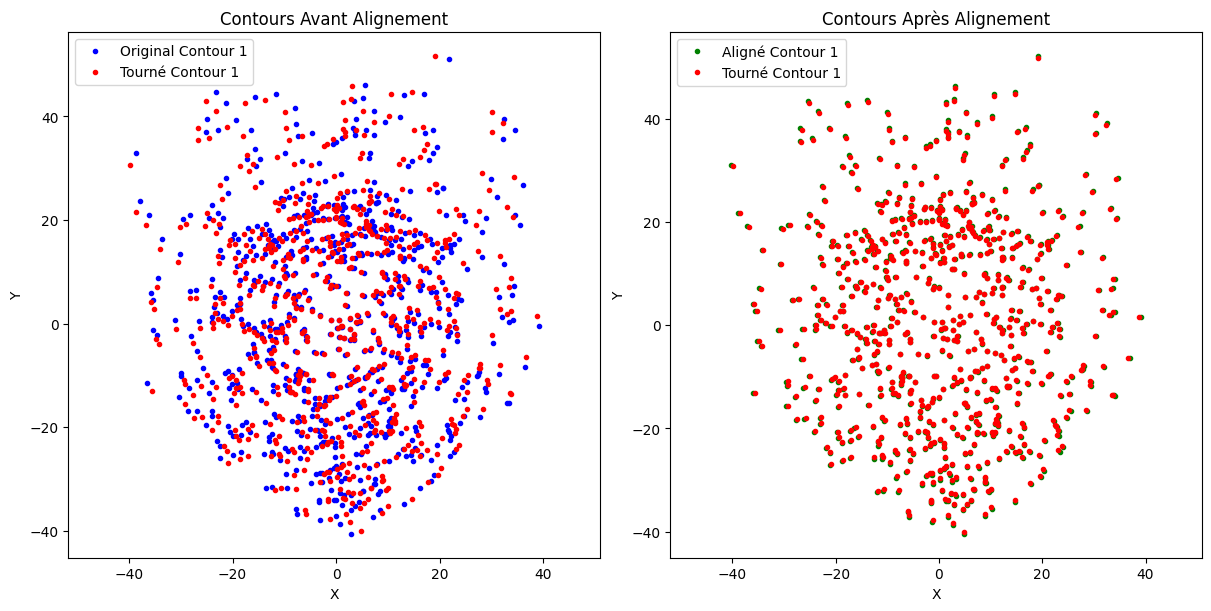

In [15]:
import matplotlib.pyplot as plt

# Fonction pour tracer les contours
def plot_contours(ax, contours, color, label_prefix):
    """
    Trace une série de contours sur un graphique.
    """
    for i, contour in enumerate(contours):
        ax.plot(contour[:, 0], contour[:, 1], '.', color=color, label=f"{label_prefix} Contour {i+1}" if i == 0 else "")
    ax.legend()

# Visualiser les contours avant et après alignement
fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

# Contours originaux et tournés (avant alignement)
axs[0].set_title("Contours Avant Alignement")
plot_contours(axs[0], original_contours, color='blue', label_prefix="Original")
plot_contours(axs[0], rotated_contours, color='red', label_prefix="Tourné")

# Contours alignés après ICP
aligned_contours = [aligned_pts[i*100:(i+1)*100] for i in range(len(target_distances))]
axs[1].set_title("Contours Après Alignement")
plot_contours(axs[1], aligned_contours, color='green', label_prefix="Aligné")
plot_contours(axs[1], rotated_contours, color='red', label_prefix="Tourné")

# Ajuster les axes et légendes
for ax in axs:
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.axis('equal')

# Afficher les graphes
plt.show()




---



---



In [16]:
def rotate_mesh(vertices, angle, axis='z'):
    """
    Applique une rotation rigide à un maillage autour d'un axe spécifié.

    Paramètres :
        vertices (ndarray) : Tableau Nx3 des sommets.
        angle (float) : Angle de rotation en radians.
        axis (str) : Axe de rotation ('x', 'y', ou 'z').

    Retourne :
        rotated_vertices (ndarray) : Sommets après rotation.
    """
    if axis == 'x':
        rotation_matrix = np.array([
            [1, 0, 0],
            [0, np.cos(angle), -np.sin(angle)],
            [0, np.sin(angle), np.cos(angle)]
        ])
    elif axis == 'y':
        rotation_matrix = np.array([
            [np.cos(angle), 0, np.sin(angle)],
            [0, 1, 0],
            [-np.sin(angle), 0, np.cos(angle)]
        ])
    elif axis == 'z':
        rotation_matrix = np.array([
            [np.cos(angle), -np.sin(angle), 0],
            [np.sin(angle), np.cos(angle), 0],
            [0, 0, 1]
        ])
    else:
        raise ValueError("L'axe doit être 'x', 'y', ou 'z'.")

    # Appliquer la rotation
    rotated_vertices = np.dot(vertices, rotation_matrix.T)
    return rotated_vertices


In [17]:
# Appliquer une rotation de 30 degrés autour de l'axe z
angle_radians = np.radians(30)  # Convertir en radians
rotated_vertices = rotate_mesh(vertices, angle_radians, axis='z')

# Vérifier les sommets transformés
print("Sommets après rotation :", rotated_vertices[:5])


Sommets après rotation : [[ 51.58794925 -89.15338515 -26.918209  ]
 [ 52.27694676 -88.88427785 -26.622235  ]
 [ 52.64411757 -88.75002035 -26.501095  ]
 [ 53.22939762 -88.47643713 -26.308213  ]
 [ 54.29763103 -88.00504368 -26.006908  ]]


In [18]:
def compute_curve_differences(original_vertices, rotated_vertices, level_curve_indices):
    """
    Calcule les distances entre les points correspondants des courbes de niveaux
    sur le maillage original et le maillage transformé.

    Paramètres :
        original_vertices (ndarray) : Sommets du maillage original.
        rotated_vertices (ndarray) : Sommets du maillage transformé.
        level_curve_indices (list) : Indices des sommets appartenant aux courbes de niveaux.

    Retourne :
        distances (list) : Liste des distances entre les points correspondants.
    """
    distances = []
    for idx in level_curve_indices:
        dist = np.linalg.norm(original_vertices[idx] - rotated_vertices[idx])
        distances.append(dist)
    return distances


In [19]:
# Visualize and compare geodesic contours
def visualize_geodesic_contours(vertices, sum_distances, target_distances, R_sim, t_sim, tolerance=0.9):
    """
    Visualize geodesic contours of the original and transformed mesh.
    """
    original_contours = []
    transformed_contours = []

    # Extract contours for each target distance
    for target_distance in target_distances:
        contour_original = extract_contour_points(vertices, sum_distances, target_distance, tolerance)
        contour_transformed = ApplyTransformation(contour_original, R_sim, t_sim)

        original_contours.append(contour_original)
        transformed_contours.append(contour_transformed)

    # Prepare plotly scatter objects
    data = []
    for i, target_distance in enumerate(target_distances):
        data.append(go.Scatter3d(
            x=original_contours[i][:, 0],
            y=original_contours[i][:, 1],
            z=original_contours[i][:, 2],
            mode='markers',
            marker=dict(size=3, color='blue'),
            name=f"Original Contour {target_distance}"
        ))
        data.append(go.Scatter3d(
            x=transformed_contours[i][:, 0],
            y=transformed_contours[i][:, 1],
            z=transformed_contours[i][:, 2],
            mode='markers',
            marker=dict(size=3, color='red'),
            name=f"Transformed Contour {target_distance}"
        ))

    # Layout for the plot
    layout = go.Layout(
        title="Superposed Geodesic Contours",
        scene=dict(
            xaxis=dict(title="X"),
            yaxis=dict(title="Y"),
            zaxis=dict(title="Z")
        ),
        width=1000,
        height=800
    )

    # Plot using plotly
    fig = go.Figure(data=data, layout=layout)
    fig.show()

# Define your parameters
target_distances = [104, 119, 129, 139, 149, 159, 174]
R_sim = np.array([[0.99, -0.05, 0], [0.05, 0.99, 0], [0, 0, 1]])
t_sim = np.array([[1, -1, 2]]).T

# Call visualization function
visualize_geodesic_contours(vertices, sum_distances, target_distances, R_sim, t_sim)

In [20]:
import numpy as np
import plotly.graph_objects as go

def compute_errors(original_contours, transformed_contours):
    """
    Compute errors (distances) between corresponding points of original and transformed contours.
    """
    errors = []
    for original, transformed in zip(original_contours, transformed_contours):
        distances = np.linalg.norm(original - transformed, axis=1)
        errors.append(distances)
    return errors

def visualize_geodesic_contours_with_errors(vertices, sum_distances, target_distances, R_sim, t_sim, tolerance=0.9):
    """
    Visualize geodesic contours of the original and transformed mesh and compute errors between them.
    """
    original_contours = []
    transformed_contours = []

    # Extract contours for each target distance
    for target_distance in target_distances:
        contour_original = extract_contour_points(vertices, sum_distances, target_distance, tolerance)
        contour_transformed = ApplyTransformation(contour_original, R_sim, t_sim)

        original_contours.append(contour_original)
        transformed_contours.append(contour_transformed)

    # Compute errors
    errors = compute_errors(original_contours, transformed_contours)
    mean_errors = [np.mean(e) for e in errors]

    # Print the error statistics
    print("Error Statistics between Original and Transformed Contours:")
    for i, target_distance in enumerate(target_distances):
        print(f"Target Distance {target_distance}: Mean Error = {mean_errors[i]:.4f}, Max Error = {np.max(errors[i]):.4f}")

    # Prepare plotly scatter objects
    data = []
    for i, target_distance in enumerate(target_distances):
        data.append(go.Scatter3d(
            x=original_contours[i][:, 0],
            y=original_contours[i][:, 1],
            z=original_contours[i][:, 2],
            mode='markers',
            marker=dict(size=3, color='blue'),
            name=f"Original Contour {target_distance}"
        ))
        data.append(go.Scatter3d(
            x=transformed_contours[i][:, 0],
            y=transformed_contours[i][:, 1],
            z=transformed_contours[i][:, 2],
            mode='markers',
            marker=dict(size=3, color='red'),
            name=f"Transformed Contour {target_distance}"
        ))

    # Layout for the plot
    layout = go.Layout(
        title="Superposed Geodesic Contours with Error Analysis",
        scene=dict(
            xaxis=dict(title="X"),
            yaxis=dict(title="Y"),
            zaxis=dict(title="Z")
        ),
        width=1000,
        height=800
    )

    # Plot using plotly
    fig = go.Figure(data=data, layout=layout)
    fig.show()

# Example Usage
target_distances = [104, 119, 129, 139, 149, 159, 174]
R_sim = np.array([[0.99, -0.05, 0], [0.05, 0.99, 0], [0, 0, 1]])
t_sim = np.array([[1, -1, 2]]).T

# Call visualization function
visualize_geodesic_contours_with_errors(vertices, sum_distances, target_distances, R_sim, t_sim)


Error Statistics between Original and Transformed Contours:
Target Distance 104: Mean Error = 2.9941, Max Error = 3.7829
Target Distance 119: Mean Error = 3.0369, Max Error = 3.9963
Target Distance 129: Mean Error = 3.0803, Max Error = 4.1070
Target Distance 139: Mean Error = 3.1442, Max Error = 4.2558
Target Distance 149: Mean Error = 3.3142, Max Error = 4.4543
Target Distance 159: Mean Error = 3.4252, Max Error = 4.6502
Target Distance 174: Mean Error = 3.6120, Max Error = 4.9048


In [26]:
def arc_length_parameterization(points, num_samples):
    """
    Resamples a curve based on arc length for uniform spacing of points.
    :param points: Nx3 numpy array representing points on the contour.
    :param num_samples: Number of points to resample.
    :return: Resampled points (Nx3).
    """
    # Compute pairwise distances between consecutive points
    distances = np.sqrt(np.sum(np.diff(points, axis=0)**2, axis=1))
    cumulative_length = np.hstack(([0], np.cumsum(distances)))

    # Normalize arc lengths to [0, 1]
    normalized_length = cumulative_length / cumulative_length[-1]

    # Interpolate to get uniform spacing
    target_lengths = np.linspace(0, 1, num_samples)
    resampled_points = np.array([
        np.interp(target_lengths, normalized_length, points[:, i])
        for i in range(points.shape[1])
    ]).T

    return resampled_points


In [27]:
def fit_bspline(points, num_samples=100):
    """
    Fits a B-spline to resampled points and returns a smooth curve.
    :param points: Nx3 numpy array representing points on the contour.
    :param num_samples: Number of points to sample on the interpolated curve.
    :return: Interpolated points (Nx3).
    """
    t = np.linspace(0, 1, len(points))
    t_new = np.linspace(0, 1, num_samples)

    # Fit splines for x, y, z coordinates
    x_spline = make_interp_spline(t, points[:, 0], k=3)
    y_spline = make_interp_spline(t, points[:, 1], k=3)
    z_spline = make_interp_spline(t, points[:, 2], k=3)

    x_new = x_spline(t_new)
    y_new = y_spline(t_new)
    z_new = z_spline(t_new)

    return np.vstack((x_new, y_new, z_new)).T


In [28]:
def sample_with_planes(points, num_planes):
    """
    Samples points along the curve by intersecting with uniform planes.
    :param points: Nx3 numpy array representing points on the curve.
    :param num_planes: Number of planes for sampling.
    :return: Resampled points (Mx3).
    """
    # Define planes orthogonal to the curve's direction
    cumulative_length = np.cumsum(np.sqrt(np.sum(np.diff(points, axis=0)**2, axis=1)))
    target_lengths = np.linspace(0, cumulative_length[-1], num_planes)

    sampled_points = []
    current_idx = 0

    for target_length in target_lengths:
        while current_idx < len(cumulative_length) and cumulative_length[current_idx] < target_length:
            current_idx += 1
        sampled_points.append(points[current_idx])

    return np.array(sampled_points)


In [29]:
def visualize_geodesic_interpolated(vertices, sum_distances, target_distances, num_samples, num_planes, R_sim, t_sim, tolerance=0.9):
    """
    Visualize geodesic contours with interpolation, arc-length parameterization, and uniform sampling.
    """
    original_contours = []
    transformed_contours = []

    for target_distance in target_distances:
        contour_original = extract_contour_points(vertices, sum_distances, target_distance, tolerance)

        # Arc-length parameterization and B-spline interpolation
        resampled_original = arc_length_parameterization(contour_original, num_samples)
        interpolated_original = fit_bspline(resampled_original, num_samples)

        # Uniform sampling via planes
        sampled_original = sample_with_planes(interpolated_original, num_planes)

        contour_transformed = ApplyTransformation(sampled_original, R_sim, t_sim)

        original_contours.append(sampled_original)
        transformed_contours.append(contour_transformed)

    # Visualization
    data = []
    for i, target_distance in enumerate(target_distances):
        data.append(go.Scatter3d(
            x=original_contours[i][:, 0],
            y=original_contours[i][:, 1],
            z=original_contours[i][:, 2],
            mode='markers+lines',
            marker=dict(size=3, color='blue'),
            name=f"Original Contour {target_distance}"
        ))
        data.append(go.Scatter3d(
            x=transformed_contours[i][:, 0],
            y=transformed_contours[i][:, 1],
            z=transformed_contours[i][:, 2],
            mode='markers+lines',
            marker=dict(size=3, color='red'),
            name=f"Transformed Contour {target_distance}"
        ))

    layout = go.Layout(
        title="Geodesic Contours with Arc-Length Parametrization and Interpolation",
        scene=dict(
            xaxis=dict(title="X"),
            yaxis=dict(title="Y"),
            zaxis=dict(title="Z")
        ),
        width=1000,
        height=800
    )

    fig = go.Figure(data=data, layout=layout)
    fig.show()


In [30]:
target_distances = [104, 119, 129, 139, 149, 159, 174]
R_sim = np.array([[0.99, -0.05, 0], [0.05, 0.99, 0], [0, 0, 1]])
t_sim = np.array([[1, -1, 2]]).T

num_samples = 95

# Call visualization function
visualize_geodesic_interpolated(vertices, sum_distances, target_distances, num_samples, 4, R_sim, t_sim, tolerance=0.3)

NameError: name 'make_interp_spline' is not defined

In [34]:
import numpy as np
import plotly.graph_objects as go
from scipy.spatial import distance

def compute_arc_length_contour(contour_points):
    """
    Compute the arc length of a contour by summing the distances between consecutive points.
    """
    arc_lengths = np.cumsum(np.linalg.norm(np.diff(contour_points, axis=0), axis=1))
    arc_lengths = np.insert(arc_lengths, 0, 0)  # Start at 0 for the first point
    return arc_lengths

def resample_contour_on_arc_length(contour_points, num_samples):
    """
    Resample the contour points based on arc length. The points are reparameterized along the contour
    such that the distance between each point is uniform along the curve.
    """
    arc_lengths = compute_arc_length_contour(contour_points)
    total_length = arc_lengths[-1]
    uniform_lengths = np.linspace(0, total_length, num_samples)

    # Interpolate to get new points at uniform arc length
    resampled_points = []
    for i in range(len(uniform_lengths)):
        idx = np.searchsorted(arc_lengths, uniform_lengths[i])
        if idx < len(contour_points) - 1:
            t = (uniform_lengths[i] - arc_lengths[idx - 1]) / (arc_lengths[idx] - arc_lengths[idx - 1])
            resampled_points.append((1 - t) * contour_points[idx - 1] + t * contour_points[idx])
        else:
            resampled_points.append(contour_points[-1])  # The last point

    return np.array(resampled_points)

def compute_errors(original_contours, transformed_contours):
    """
    Compute errors (distances) between corresponding points of original and transformed contours.
    """
    errors = []
    for original, transformed in zip(original_contours, transformed_contours):
        distances = np.linalg.norm(original - transformed, axis=1)
        errors.append(distances)
    return errors

def visualize_geodesic_contours_with_mesh_and_errors(
    vertices, faces, sum_distances, target_distances, R_sim, t_sim, num_samples=95, tolerance=0.9):
    """
    Visualize smooth geodesic contours overlaid on a 3D mesh with error analysis.
    """
    original_contours = []
    transformed_contours = []

    for target_distance in target_distances:
        # Extract and smooth the original contour
        contour_original = extract_contour_points(vertices, sum_distances, target_distance, tolerance)
        resampled_original = resample_contour_on_arc_length(contour_original, num_samples)

        # Transform and smooth the transformed contour
        contour_transformed = ApplyTransformation(resampled_original, R_sim, t_sim)

        original_contours.append(resampled_original)
        transformed_contours.append(contour_transformed)

    # Compute errors
    errors = compute_errors(original_contours, transformed_contours)
    mean_errors = [np.mean(e) for e in errors]
    min_errors = [np.min(e) for e in errors]

    # Print error statistics
    print("Error Statistics between Original and Transformed Contours:")
    for i, target_distance in enumerate(target_distances):
        print(f"Target Distance {target_distance}: Mean Error = {mean_errors[i]:.4f}, Min Error = {min_errors[i]:.4f}")

    # Prepare Plotly data for mesh and contours
    mesh = go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        opacity=0.5,
        color='lightgray',
        name="Mesh"
    )
    data = [mesh]

    for i, target_distance in enumerate(target_distances):
        # Original Contour
        data.append(go.Scatter3d(
            x=original_contours[i][:, 0],
            y=original_contours[i][:, 1],
            z=original_contours[i][:, 2],
            mode='lines+markers',
            marker=dict(size=4, color='blue'),
            line=dict(color='blue', width=3),
            name=f"Original {target_distance}"
        ))
        # Transformed Contour
        data.append(go.Scatter3d(
            x=transformed_contours[i][:, 0],
            y=transformed_contours[i][:, 1],
            z=transformed_contours[i][:, 2],
            mode='lines+markers',
            marker=dict(size=4, color='red'),
            line=dict(color='red', width=3),
            name=f"Transformed {target_distance}"
        ))

    # Layout with larger legend
    layout = go.Layout(
        title="3D Mesh with Geodesic Contours and Error Analysis",
        scene=dict(
            xaxis=dict(title="X"),
            yaxis=dict(title="Y"),
            zaxis=dict(title="Z")
        ),
        width=1200,
        height=900,
        legend=dict(
            font=dict(size=12),
            itemsizing='constant'
        )
    )

    # Plot
    fig = go.Figure(data=data, layout=layout)
    fig.show()

# Example Usage
target_distances = [104, 119, 129, 139, 149, 159, 174]
R_sim = np.array([[0.99, -0.05, 0], [0.05, 0.99, 0], [0, 0, 1]])
t_sim = np.array([[1, -1, 2]]).T

# Call visualization function
visualize_geodesic_contours_with_mesh_and_errors(vertices, faces, sum_distances, target_distances, R_sim, t_sim)


Error Statistics between Original and Transformed Contours:
Target Distance 104: Mean Error = 2.9548, Min Error = 2.2747
Target Distance 119: Mean Error = 2.9837, Min Error = 2.1624
Target Distance 129: Mean Error = 2.9753, Min Error = 2.1223
Target Distance 139: Mean Error = 3.0576, Min Error = 2.1038
Target Distance 149: Mean Error = 3.0039, Min Error = 2.0279
Target Distance 159: Mean Error = 3.1194, Min Error = 2.0179
Target Distance 174: Mean Error = 3.2680, Min Error = 2.0072


In [41]:
import numpy as np

def FindNeighborPoints(source_pts, target_pts):
    """
    Find the closest points in the target mesh for each point in the source mesh.
    """
    distances = np.linalg.norm(source_pts[:, np.newaxis] - target_pts, axis=2)
    closest_points = target_pts[np.argmin(distances, axis=1)]
    return closest_points

def RegisterPoints(source_pts, target_pts):
    """
    Compute the rigid transformation (rotation and translation) that best aligns source_pts with target_pts.
    This can be done using SVD (Singular Value Decomposition) or other methods.
    """
    centroid_source = np.mean(source_pts, axis=0)
    centroid_target = np.mean(target_pts, axis=0)

    # Center the points
    source_centered = source_pts - centroid_source
    target_centered = target_pts - centroid_target


    source_centered = source_pts.reshape(-1, 3)  # Ensure it's of shape (N, 3)
    target_centered = target_pts.reshape(-1, 3)  # Ensure it's of shape (N, 3)


    # Compute the covariance matrix
    H = np.dot(source_centered.T, target_centered)

    # Perform Singular Value Decomposition
    U, _, Vt = np.linalg.svd(H)

    # Compute rotation matrix
    R = np.dot(Vt.T, U.T)

    # Compute translation vector
    t = centroid_target - np.dot(R, centroid_source)

    return R, t

def ApplyTransformation(points, R, t):
    """
    Apply the rigid transformation (R, t) to the points.
    """
    return np.dot(points, R.T) + t.T

def ComputeRMSE(source_pts, target_pts):
    """
    Compute the Root Mean Squared Error between the source points and the target points.
    """
    return np.sqrt(np.mean(np.linalg.norm(source_pts - target_pts, axis=1)**2))

def IterativeClosestPoint(source_pts, target_pts, tau=10e-6, epsilon=10e-3, max_iterations=1000):
    """
    Iterative Closest Point (ICP) Algorithm.
    """
    current_pts = source_pts.copy()
    last_rmse = float('inf')
    k = 0
    t_total = np.zeros((3, 1))
    R_total = np.eye(3)

    while k < max_iterations:
        # Find closest points
        neigh_pts = FindNeighborPoints(current_pts, target_pts)

        # Compute transformation
        R, t = RegisterPoints(current_pts, neigh_pts)

        # Apply transformation
        current_pts = ApplyTransformation(current_pts, R, t)

        # Accumulate transformations
        R_total = R @ R_total
        t_total = R @ t_total + t

        # Compute RMSE
        rmse = ComputeRMSE(current_pts, neigh_pts)
        if abs(last_rmse - rmse) < tau or rmse < epsilon:
            break

        last_rmse = rmse
        k += 1

    return current_pts, R_total, t_total, rmse

def compute_errors(original_contours, transformed_contours):
    """
    Compute errors (distances) between corresponding points of original and transformed contours.
    """
    errors = []
    for original, transformed in zip(original_contours, transformed_contours):
        distances = np.linalg.norm(original - transformed, axis=1)
        errors.append(distances)
    return errors

def visualize_geodesic_contours_with_mesh_and_errors(
    vertices, faces, sum_distances, target_distances, R_sim, t_sim, num_samples=95, tolerance=0.9):
    """
    Visualize smooth geodesic contours overlaid on a 3D mesh with error analysis.
    """
    original_contours = []
    transformed_contours = []

    for target_distance in target_distances:
        # Extract and smooth the original contour
        contour_original = extract_contour_points(vertices, sum_distances, target_distance, tolerance)
        resampled_original = resample_contour_on_arc_length(contour_original, num_samples)

        # Transform and smooth the transformed contour
        contour_transformed = ApplyTransformation(resampled_original, R_sim, t_sim)

        original_contours.append(resampled_original)
        transformed_contours.append(contour_transformed)

    # Apply ICP to align contours
    aligned_contours, R_aligned, t_aligned, icp_rmse = IterativeClosestPoint(np.array(transformed_contours), np.array(original_contours))

    # Compute errors
    errors = compute_errors(original_contours, aligned_contours)
    mean_errors = [np.mean(e) for e in errors]
    min_errors = [np.min(e) for e in errors]

    # Print error statistics
    print("Error Statistics after ICP:")
    for i, target_distance in enumerate(target_distances):
        print(f"Target Distance {target_distance}: Mean Error = {mean_errors[i]:.4f}, Min Error = {min_errors[i]:.4f}, ICP RMSE = {icp_rmse:.4f}")

    # Prepare Plotly data for mesh and contours
    mesh = go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        opacity=0.5,
        color='lightgray',
        name="Mesh"
    )
    data = [mesh]

    for i, target_distance in enumerate(target_distances):
        # Original Contour
        data.append(go.Scatter3d(
            x=original_contours[i][:, 0],
            y=original_contours[i][:, 1],
            z=original_contours[i][:, 2],
            mode='lines+markers',
            marker=dict(size=4, color='blue'),
            line=dict(color='blue', width=3),
            name=f"Original {target_distance}"
        ))
        # Transformed Contour
        data.append(go.Scatter3d(
            x=transformed_contours[i][:, 0],
            y=transformed_contours[i][:, 1],
            z=transformed_contours[i][:, 2],
            mode='lines+markers',
            marker=dict(size=4, color='red'),
            line=dict(color='red', width=3),
            name=f"Transformed {target_distance}"
        ))

    # Layout with larger legend
    layout = go.Layout(
        title="3D Mesh with Geodesic Contours and Error Analysis",
        scene=dict(
            xaxis=dict(title="X"),
            yaxis=dict(title="Y"),
            zaxis=dict(title="Z")
        ),
        width=1200,
        height=900,
        legend=dict(
            font=dict(size=12),
            itemsizing='constant'
        )
    )

    # Plot
    fig = go.Figure(data=data, layout=layout)
    fig.show()

# Example Usage
target_distances = [104, 119, 129, 139, 149, 159, 174]
R_sim = np.array([[0.99, -0.05, 0], [0.05, 0.99, 0], [0, 0, 1]])
t_sim = np.array([[1, -1, 2]]).T

# Call visualization function
visualize_geodesic_contours_with_mesh_and_errors(vertices, faces, sum_distances, target_distances, R_sim, t_sim)


ValueError: shapes (3,665) and (1995,3) not aligned: 665 (dim 1) != 1995 (dim 0)

In [42]:
import numpy as np
import plotly.graph_objects as go

def compute_errors(original_contours, transformed_contours):
    """
    Calcule les erreurs (distances) entre les points correspondants des contours originaux et transformés.
    """
    errors = []
    for original, transformed in zip(original_contours, transformed_contours):
        # Calcul de la distance entre chaque paire de points correspondants
        distances = np.linalg.norm(original - transformed, axis=1)
        errors.append(distances)
    return errors

def visualize_geodesic_contours_with_errors(vertices, sum_distances, target_distances, R_sim, t_sim, tolerance=0.9):
    """
    Visualise les contours géodésiques du maillage original et transformé, puis calcule les erreurs entre eux.
    """
    original_contours = []  # Liste des contours originaux
    transformed_contours = []  # Liste des contours transformés

    # Extraire les contours pour chaque distance cible
    for target_distance in target_distances:
        contour_original = extract_contour_points(vertices, sum_distances, target_distance, tolerance)
        contour_transformed = ApplyTransformation(contour_original, R_sim, t_sim)

        original_contours.append(contour_original)  # Ajouter le contour original
        transformed_contours.append(contour_transformed)  # Ajouter le contour transformé

    # Calcul des erreurs
    errors = compute_errors(original_contours, transformed_contours)
    mean_errors = [np.mean(e) for e in errors]  # Calcul de l'erreur moyenne

    # Affichage des statistiques d'erreur
    print("Statistiques des erreurs entre les contours originaux et transformés :")
    for i, target_distance in enumerate(target_distances):
        print(f"Distance lambda = {target_distance}: Erreur Moyenne = {mean_errors[i]:.4f}, Erreur Maximale = {np.max(errors[i]):.4f}")

    # Préparation des objets scatter pour Plotly
    data = []
    for i, target_distance in enumerate(target_distances):
        # Contours originaux en bleu
        data.append(go.Scatter3d(
            x=original_contours[i][:, 0],
            y=original_contours[i][:, 1],
            z=original_contours[i][:, 2],
            mode='markers',
            marker=dict(size=3, color='blue'),
            name=f"Contour Original {target_distance}"
        ))
        # Contours transformés en rouge
        data.append(go.Scatter3d(
            x=transformed_contours[i][:, 0],
            y=transformed_contours[i][:, 1],
            z=transformed_contours[i][:, 2],
            mode='markers',
            marker=dict(size=3, color='red'),
            name=f"Contour Transformé {target_distance}"
        ))

    # Mise en page du graphique
    layout = go.Layout(
        title="Contours Géodésiques Superposés avec Analyse des Erreurs",
        scene=dict(
            xaxis=dict(title="X"),
            yaxis=dict(title="Y"),
            zaxis=dict(title="Z")
        ),
        width=1000,
        height=800
    )

    # Affichage du graphique avec Plotly
    fig = go.Figure(data=data, layout=layout)
    fig.show()

# Exemple d'utilisation
target_distances = [104, 119, 129, 139, 149, 159, 174]
R_sim = np.array([[0.99, -0.05, 0], [0.05, 0.99, 0], [0, 0, 1]])  # Matrice de rotation
t_sim = np.array([[1, -1, 2]]).T  # Vecteur de translation

# Appel de la fonction de visualisation
visualize_geodesic_contours_with_errors(vertices, sum_distances, target_distances, R_sim, t_sim)


Statistiques des erreurs entre les contours originaux et transformés :
Distance cible 104: Erreur Moyenne = 2.9941, Erreur Maximale = 3.7829
Distance cible 119: Erreur Moyenne = 3.0369, Erreur Maximale = 3.9963
Distance cible 129: Erreur Moyenne = 3.0803, Erreur Maximale = 4.1070
Distance cible 139: Erreur Moyenne = 3.1442, Erreur Maximale = 4.2558
Distance cible 149: Erreur Moyenne = 3.3142, Erreur Maximale = 4.4543
Distance cible 159: Erreur Moyenne = 3.4252, Erreur Maximale = 4.6502
Distance cible 174: Erreur Moyenne = 3.6120, Erreur Maximale = 4.9048
